# AAE Raman -> Single-Cell Training (Reorganized)

This notebook reorganizes the AAE workflow from `AAE_Raman_single_cell_analysis.ipynb`.
- Functions grouped together.
- Training steps grouped together.
- Each figure in its own cell, saved to `results/figure4` as pdf/svg/png.


In [31]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import scanpy as sc
import anndata
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Global config
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results/figure4")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = RESULTS_DIR
sc.settings.autoshow = False


Using device: cuda


In [32]:
def ensure_dense(x):
    if sp.sparse.issparse(x):
        return x.toarray()
    if hasattr(x, "toarray"):
        return x.toarray()
    if hasattr(x, "todense"):
        return np.asarray(x.todense())
    return np.asarray(x)


def save_figure(fig, name, dpi=300, show=True):
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(RESULTS_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def plot_loss_curve(losses, title, ylabel, name):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(losses, lw=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    # save_figure(fig, name)


def plot_roc_multiclass(y_true, y_score, class_names, name):
    y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("ROC Curves (One-vs-Rest)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    save_figure(fig, name)


def plot_expression_consistency(
    adata,
    genes,
    batch_key="batch",
    group_key="cell_type",
    batch_a="SingleCell",
    batch_b="Raman_Train",
    title="Expression Consistency",
    name="expr_consistency",
):
    genes = [g for g in genes if g in adata.var_names]
    if len(genes) == 0:
        print("No genes found for plotting.")
        return

    df = []
    for ct in adata.obs[group_key].unique():
        for b in [batch_a, batch_b]:
            sub = adata[(adata.obs[group_key] == ct) & (adata.obs[batch_key] == b)]
            if sub.n_obs == 0:
                continue
            expr = np.asarray(sub[:, genes].X)
            if sp.sparse.issparse(expr):
                expr = expr.toarray()
            mean_expr = expr.mean(axis=0)
            for g, val in zip(genes, mean_expr):
                df.append({"cell_type": ct, "batch": b, "gene": g, "mean_expr": val})

    df = pd.DataFrame(df)
    df_a = df[df["batch"] == batch_a].set_index(["cell_type", "gene"])
    df_b = df[df["batch"] == batch_b].set_index(["cell_type", "gene"])
    df_join = df_a.join(df_b, lsuffix="_a", rsuffix="_b", how="inner")

    fig, ax = plt.subplots(figsize=(6, 5))
    for ct in df_join.index.get_level_values(0).unique():
        sub = df_join.loc[ct]
        ax.scatter(sub["mean_expr_a"], sub["mean_expr_b"], label=str(ct), s=30, alpha=0.8)
    ax.set_xlabel(f"{batch_a} mean expression")
    ax.set_ylabel(f"{batch_b} mean expression")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    save_figure(fig, name)


def get_model_device(model):
    return next(model.parameters()).device


In [33]:
class StandardEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512):
        super(StandardEncoder, self).__init__()
        self.part1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.to_mean = nn.Linear(hidden_dim, latent_dim)
        self.to_logvar = nn.Linear(hidden_dim, latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        x = self.part1(x)
        return self.to_mean(x), self.to_logvar(x)


class StandardDecoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512, no_final_relu=False):
        super(StandardDecoder, self).__init__()
        if no_final_relu:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim),
                nn.ReLU(),
            )
        self.latent_dim = latent_dim

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, latent_dim, spectral=True, end_dim=2):
        super(Discriminator, self).__init__()
        if spectral:
            self.net = nn.Sequential(
                nn.utils.spectral_norm(nn.Linear(latent_dim, 1 << 6)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 6, 1 << 5)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 5, 1 << 5)),
                nn.ReLU(),
                nn.utils.spectral_norm(nn.Linear(1 << 5, end_dim)),
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(latent_dim, 1 << 6),
                nn.ReLU(),
                nn.Linear(1 << 6, 1 << 5),
                nn.ReLU(),
                nn.Linear(1 << 5, 1 << 5),
                nn.ReLU(),
                nn.Linear(1 << 5, end_dim),
            )

    def forward(self, x):
        return self.net(x)


class VAE(nn.Module):
    def __init__(self, encoder, decoder, is_vae=True, use_latent_norm=True):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.is_vae = is_vae
        self.latent_normalizer = nn.BatchNorm1d(self.encoder.latent_dim)
        self.use_latent_norm = use_latent_norm

    def reparam_trick(self, mean, logvar):
        # VAE: sample; AE: deterministic (return mean)
        if not self.is_vae:
            return mean
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        return mean + eps * sigma

    def get_latent(self, x):
        mean, logvar = self.encoder(x)

        # ✅ AE 模式：logvar 不参与任何 BN（避免污染 running stats）
        if not self.is_vae:
            latent = mean
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)
            return latent

        # ✅ VAE 模式：按你原来的思路（可选择是否也 BN logvar）
        if self.use_latent_norm:
            mean = self.latent_normalizer(mean)
            # 这行可留可不留；保守起见我不对 logvar 用同一个 BN
            # logvar = self.latent_normalizer(logvar)
        latent = self.reparam_trick(mean, logvar)
        if self.use_latent_norm:
            latent = self.latent_normalizer(latent)
        return latent

    def forward(self, x, noise_latent_lambda=0.0):
        mean, logvar = self.encoder(x)

        if not self.is_vae:
            latent = mean
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)
        else:
            if self.use_latent_norm:
                mean = self.latent_normalizer(mean)
                # 同上：通常不建议用同一个 BN 去处理 logvar
                # logvar = self.latent_normalizer(logvar)
            latent = self.reparam_trick(mean, logvar)
            if self.use_latent_norm:
                latent = self.latent_normalizer(latent)

        if noise_latent_lambda:
            latent = latent + noise_latent_lambda * torch.randn_like(latent)

        recon_x = self.decoder(latent)
        return recon_x, mean, logvar, latent


In [34]:
def old_vae_loss(x, recon_x, mean, logvar, weights=None, this_lambda=0.0):
    if weights is None:
        bce = F.mse_loss(recon_x, x)
    else:
        bce = torch.sum(((recon_x - x) ** 2) * weights)
    kl_div = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return bce + this_lambda * kl_div


def discrim_loss(pred, true):
    return F.binary_cross_entropy_with_logits(pred, true)


def adv_vae_loss(x, recon_x, mean, logvar, discrim_preds, alpha, beta, weights=None):
    vae_part_loss = old_vae_loss(x, recon_x, mean, logvar, weights=weights)
    source_label = [1.0, 0.0]
    discrim_labels = torch.tensor([source_label] * x.shape[0]).to(x.device)
    total_discrim_loss = F.binary_cross_entropy_with_logits(discrim_preds, discrim_labels)
    discrim_part_loss = beta * total_discrim_loss
    return alpha * vae_part_loss + discrim_part_loss, vae_part_loss, total_discrim_loss


In [35]:
# ==== MODIFIED (2026-03-19) ====
# Purpose: Use SC normalized layer (layers['data']) so SC/Raman inputs share the same scale.
# ===============================
abc_ad = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
raman_ad = sc.read_h5ad("./data/raman_B.h5ad")

highly_variable_genes = abc_ad.var_names[abc_ad.var["highly_variable"]]
train_feature_ad = abc_ad[:, highly_variable_genes].copy()

# Keep SC and Raman on the same scale: use normalized SC layer as training target
if "data" not in train_feature_ad.layers:
    raise KeyError("train_feature_ad.layers['data'] is required but not found.")
train_feature = ensure_dense(train_feature_ad.layers["data"])
raman_X = ensure_dense(raman_ad.X)

print(abc_ad)
print(raman_ad)
print("SC train matrix from layer=data:", train_feature.shape, "Raman matrix:", raman_X.shape)


AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'data'
    obsp: 'connectivities', 'dist

In [36]:
# Fixed cell type order and hard-coded colors (match LDA plots)
ORDER = ["HSC", "Pro B", "Pre B", "Naive B"]
class_color_map = {
    "HSC": "#1f77b4",    # blue
    "Pro B": "#17becf",  # cyan
    "Pre B": "#e377c2",  # pink
    "Naive B": "#d62728" # red
}
classes = np.array(ORDER)
abc_ad.obs["cell_type"] = pd.Categorical(abc_ad.obs["cell_type"], categories=classes, ordered=True)
train_feature_ad.obs["cell_type"] = pd.Categorical(train_feature_ad.obs["cell_type"], categories=classes, ordered=True)
raman_ad.obs["cell_type"] = pd.Categorical(raman_ad.obs["cell_type"], categories=classes, ordered=True)
abc_ad.uns["cell_type_colors"] = [class_color_map[c] for c in classes]
palette = [class_color_map[c] for c in classes]

cell_type_sorted = abc_ad.obs["cell_type"].astype(str).values
row_colors = np.array([class_color_map[ct] for ct in cell_type_sorted])


In [37]:
labels = train_feature_ad.obs["cell_type"].astype(str)
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

train_data, test_data, train_labels, test_labels = train_test_split(
    train_feature,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded,
)

train_tensor = torch.tensor(train_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

batch_size = 1 << 5
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(train_tensor.shape, test_tensor.shape)


torch.Size([750, 2000]) torch.Size([188, 2000])


In [38]:
# ==== MODIFIED (2026-03-19) ====
# Purpose: Disable latent BN in ref_vae (use_latent_norm=False) and keep corrected epoch loss averaging.
# ===============================
epochs_ref_vae = 10
input_dim = train_data.shape[1]

ref_vae = VAE(
    StandardEncoder(input_dim, 1 << 7, hidden_dim=1 << 11),
    StandardDecoder(input_dim, 1 << 7, hidden_dim=1 << 11),
    is_vae=False,
    use_latent_norm=False,
).to(device)

ref_vae_opt = optim.Adam(ref_vae.parameters(), lr=1e-3)

ref_vae_losses = []
for epoch in range(1, epochs_ref_vae + 1):
    epoch_loss = 0.0
    seen = 0
    for _id, (batch, labels) in enumerate(train_loader):
        batch = batch.to(device)
        ref_vae_opt.zero_grad()
        recon_x, mean, logvar, latent = ref_vae(batch)
        batch_loss = old_vae_loss(batch, recon_x, mean, logvar, weights=None)
        batch_loss.backward()
        ref_vae_opt.step()
        bs = batch.size(0)
        epoch_loss += batch_loss.item() * bs
        seen += bs
    avg_loss = epoch_loss / max(seen, 1)
    ref_vae_losses.append(avg_loss)
    print(f"RefVAE Epoch {epoch}: avg_loss={avg_loss:.6f}")


RefVAE Epoch 1: avg_loss=0.351152
RefVAE Epoch 2: avg_loss=0.316276
RefVAE Epoch 3: avg_loss=0.311841
RefVAE Epoch 4: avg_loss=0.305812
RefVAE Epoch 5: avg_loss=0.303643
RefVAE Epoch 6: avg_loss=0.302912
RefVAE Epoch 7: avg_loss=0.306318
RefVAE Epoch 8: avg_loss=0.303013
RefVAE Epoch 9: avg_loss=0.302798
RefVAE Epoch 10: avg_loss=0.304797


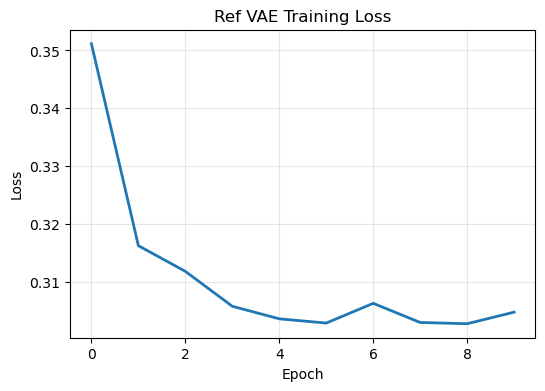

In [39]:
plot_loss_curve(ref_vae_losses, "Ref VAE Training Loss", "Loss", "ref_vae_train_loss")


In [40]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
ref_vae_eval = ref_vae.to(device).eval()
with torch.no_grad():
    train_tensor_dev = torch.tensor(train_data, dtype=torch.float32, device=get_model_device(ref_vae_eval))
    test_tensor_dev = torch.tensor(test_data, dtype=torch.float32, device=get_model_device(ref_vae_eval))
    _, _, _, latent_train = ref_vae_eval(train_tensor_dev)
    _, _, _, latent_test = ref_vae_eval(test_tensor_dev)

latent_train = latent_train.detach().cpu()
latent_test = latent_test.detach().cpu()

latent_dim = 1 << 7
num_classes = len(np.unique(train_labels))

celltype_classifier = Discriminator(latent_dim, end_dim=num_classes).to(device)
celltype_classifier_opt = optim.Adam(celltype_classifier.parameters(), lr=1e-3)

class_weights = torch.tensor([
    float(len(train_labels)) / np.sum(train_labels == class_label)
    for class_label in range(num_classes)
], dtype=torch.float32).to(device)
criter = nn.CrossEntropyLoss(weight=class_weights)

celltype_data_loader = DataLoader(
    TensorDataset(latent_train, torch.tensor(train_labels, dtype=torch.long)),
    batch_size=batch_size,
    shuffle=True,
)

classifier_loss_history = []
classifier_acc_history = []

epochs_classifier = 50
for epoch in range(1, epochs_classifier + 1):
    epoch_loss = 0.0
    correct = 0
    total = 0
    for this_batch, this_label in celltype_data_loader:
        this_batch = this_batch.to(device)
        this_label = this_label.to(device)
        celltype_classifier_opt.zero_grad()
        logits = celltype_classifier(this_batch.float())
        loss = criter(logits, this_label)
        loss.backward()
        celltype_classifier_opt.step()
        epoch_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == this_label).sum().item()
        total += this_label.size(0)
    avg_loss = epoch_loss / len(celltype_data_loader.dataset)
    acc = correct / total
    classifier_loss_history.append(avg_loss)
    classifier_acc_history.append(acc)
    print(f"Classifier Epoch {epoch}: avg_loss={avg_loss:.6f}, acc={acc:.4f}")


Classifier Epoch 1: avg_loss=0.028950, acc=0.8600
Classifier Epoch 2: avg_loss=0.008795, acc=0.9707
Classifier Epoch 3: avg_loss=0.005687, acc=0.9640
Classifier Epoch 4: avg_loss=0.004177, acc=0.9747
Classifier Epoch 5: avg_loss=0.004535, acc=0.9733
Classifier Epoch 6: avg_loss=0.005214, acc=0.9680
Classifier Epoch 7: avg_loss=0.003643, acc=0.9747
Classifier Epoch 8: avg_loss=0.003825, acc=0.9733
Classifier Epoch 9: avg_loss=0.003438, acc=0.9773
Classifier Epoch 10: avg_loss=0.003341, acc=0.9733
Classifier Epoch 11: avg_loss=0.003891, acc=0.9720
Classifier Epoch 12: avg_loss=0.004053, acc=0.9680
Classifier Epoch 13: avg_loss=0.003154, acc=0.9773
Classifier Epoch 14: avg_loss=0.003239, acc=0.9773
Classifier Epoch 15: avg_loss=0.003079, acc=0.9760
Classifier Epoch 16: avg_loss=0.003630, acc=0.9760
Classifier Epoch 17: avg_loss=0.003669, acc=0.9760
Classifier Epoch 18: avg_loss=0.003451, acc=0.9773
Classifier Epoch 19: avg_loss=0.003722, acc=0.9773
Classifier Epoch 20: avg_loss=0.003295, 

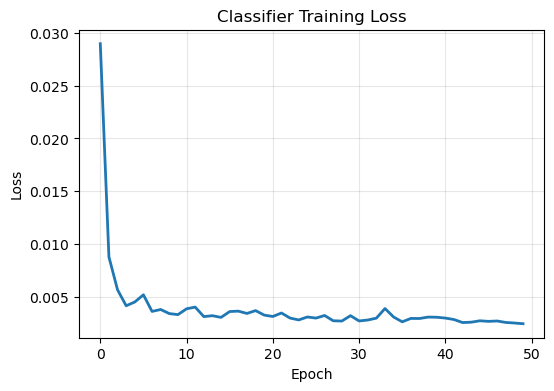

In [41]:
plot_loss_curve(classifier_loss_history, "Classifier Training Loss", "Loss", "classifier_train_loss")


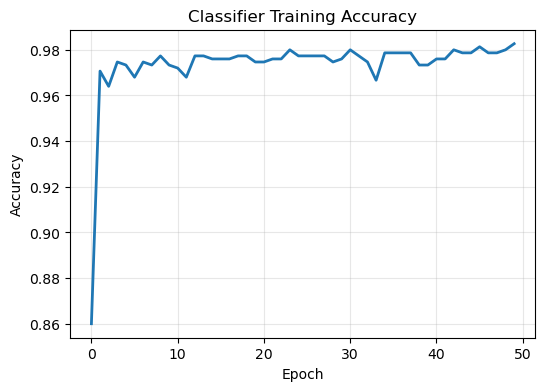

In [42]:
plot_loss_curve(classifier_acc_history, "Classifier Training Accuracy", "Accuracy", "classifier_train_accuracy")


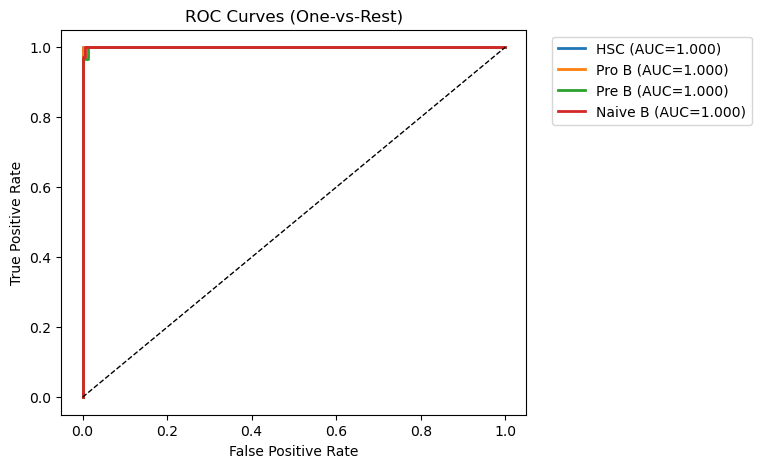

LabelEncoder order: ['HSC', 'Naive B', 'Pre B', 'Pro B']
Holdout test accuracy: 0.9840425531914894
Confusion matrix (rows=true, cols=pred):
[[53  0  0  0]
 [ 0 69  0  0]
 [ 0  0 28  3]
 [ 0  0  0 35]]


In [43]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
celltype_classifier_eval = celltype_classifier.to(device).eval()
with torch.no_grad():
    latent_test_dev = latent_test.to(get_model_device(celltype_classifier_eval))
    test_logits = celltype_classifier_eval(latent_test_dev.float())
    test_probs = torch.softmax(test_logits, dim=1).cpu().numpy()

plot_roc_multiclass(test_labels, test_probs, classes, "classifier_roc")

from sklearn.metrics import confusion_matrix
pred_test = np.argmax(test_probs, axis=1)
test_acc = np.mean(pred_test == test_labels)
print('LabelEncoder order:', list(label_encoder.classes_))
print('Holdout test accuracy:', float(test_acc))
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(test_labels, pred_test))


In [44]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# Validation 1: Cross-validated ROC on single-cell latent (to reduce optimistic split effects)
from sklearn.model_selection import StratifiedKFold

ref_vae_eval = ref_vae.to(device).eval()
with torch.no_grad():
    all_tensor_dev = torch.tensor(train_feature, dtype=torch.float32, device=get_model_device(ref_vae_eval))
    _, _, _, latent_all = ref_vae_eval(all_tensor_dev)

X_latent = latent_all.detach().cpu().numpy()
y_all = labels_encoded

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_aucs = []

for fold, (tr, te) in enumerate(skf.split(X_latent, y_all), 1):
    clf = Discriminator(latent_dim, end_dim=len(classes)).to(device)
    opt = optim.Adam(clf.parameters(), lr=1e-3)
    weights = torch.tensor([
        float(len(tr)) / np.sum(y_all[tr] == k) for k in range(len(classes))
    ], dtype=torch.float32).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    ds = TensorDataset(
        torch.tensor(X_latent[tr], dtype=torch.float32),
        torch.tensor(y_all[tr], dtype=torch.long),
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    # short training (keep it light)
    for _ in range(15):
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            logits = clf(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    clf = clf.to("cpu")
    with torch.no_grad():
        logits = clf(torch.tensor(X_latent[te], dtype=torch.float32, device=get_model_device(clf)))
        probs = torch.softmax(logits, dim=1).numpy()

    # macro AUC for the fold
    y_bin = label_binarize(y_all[te], classes=list(range(len(classes))))
    fold_aucs = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        fold_aucs.append(auc(fpr, tpr))
    cv_aucs.append(np.mean(fold_aucs))
    print(f"Fold {fold}: macro AUC = {cv_aucs[-1]:.4f}")

print(f"CV macro AUC (mean ± std): {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

Fold 1: macro AUC = 0.9986
Fold 2: macro AUC = 0.9939
Fold 3: macro AUC = 0.9991
Fold 4: macro AUC = 0.9857
Fold 5: macro AUC = 0.9960
CV macro AUC (mean ± std): 0.9946 ± 0.0049


In [45]:
raman_y = label_encoder.transform(raman_ad.obs["cell_type"].astype(str).values)
raman_X_train, raman_X_test, raman_y_train, raman_y_test = train_test_split(
    raman_X,
    raman_y,
    test_size=0.2,
    random_state=42,
    stratify=raman_y,
)

raman_index = raman_ad.obs.index
raman_index_train, raman_index_test = train_test_split(
    raman_index,
    test_size=0.2,
    random_state=42,
    stratify=raman_y,
)

raman_train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_train).float(),
        torch.from_numpy(raman_y_train).long(),
    ),
    batch_size=batch_size,
    shuffle=True,
)

raman_test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(raman_X_test).float(),
        torch.from_numpy(raman_y_test).long(),
    ),
    batch_size=batch_size,
    shuffle=False,
)


In [46]:
# ==== MODIFIED (2026-03-19) ====
# Purpose: Revert to original latent-only loss design (recon + adv + celltype),
#          with original weights alpha=1, beta=3e-4, raman_beta=50, and no latent BN.
# ===============================
latent_dim = 1 << 7
ref_vae = ref_vae.to(device)

input_cell_dim = raman_X.shape[1]
raman_vae = VAE(
    StandardEncoder(input_cell_dim, latent_dim, hidden_dim=1 << 11),
    StandardDecoder(input_cell_dim, latent_dim, hidden_dim=1 << 11, no_final_relu=True),
    is_vae=False,
    use_latent_norm=False,
).to(device)
raman_opt = optim.Adam(raman_vae.parameters(), lr=5e-5)

raman_discrim = Discriminator(latent_dim).to(device)
raman_discrim_opt = optim.Adam(raman_discrim.parameters(), lr=4e-3)

# Match original loss proportions (latent-focused)
alpha = 1.0
beta = 3e-4
raman_beta = 50.0

celltype_classifier = celltype_classifier.to(device)

ref_data_loader = DataLoader(
    TensorDataset(torch.from_numpy(train_feature).float()),
    batch_size=batch_size,
    shuffle=True,
)

epochs_raman = 50
loss_adv = []
loss_vae = []
loss_celltype = []
loss_discrim = []

for epoch in range(1, epochs_raman + 1):
    discrim_epoch_loss = 0.0
    vae_part_epoch_loss = 0.0
    raman_vae_epoch_loss = 0.0
    celltype_part_epoch_loss = 0.0
    seen = 0

    for _id, ([ref_batch], [raman_batch, raman_celltypes]) in enumerate(
        zip(ref_data_loader, raman_train_loader)
    ):
        raman_opt.zero_grad()
        raman_discrim_opt.zero_grad()

        ref_batch = ref_batch.to(device)
        raman_batch = raman_batch.to(device)
        raman_celltypes = raman_celltypes.to(device)
        bs = raman_batch.size(0)

        ref_encoded = ref_vae.get_latent(ref_batch).detach()
        raman_encoded = raman_vae.get_latent(raman_batch).detach()

        source_label, target_label = [1.0, 0.0], [0.0, 1.0]
        encodeds = torch.cat((ref_encoded, raman_encoded), axis=0)
        discrim_labels = torch.tensor(
            [source_label] * ref_encoded.shape[0] + [target_label] * raman_encoded.shape[0]
        ).to(device)

        pred_discrim_labels = raman_discrim(encodeds)
        batch_discrim_loss = discrim_loss(pred_discrim_labels, discrim_labels)
        batch_discrim_loss.backward()
        discrim_epoch_loss += batch_discrim_loss.item() * bs
        raman_discrim_opt.step()

        for param in raman_discrim.parameters():
            param.requires_grad = False

        recon_raman_batch, raman_batch_mean, raman_batch_logvar, raman_batch_latent = raman_vae(raman_batch)
        raman_vae_discrim_preds = raman_discrim(raman_batch_latent)

        raman_vae_batch_loss, vae_part_batch_loss, _ = adv_vae_loss(
            raman_batch.detach(),
            recon_raman_batch,
            raman_batch_mean,
            raman_batch_logvar,
            raman_vae_discrim_preds,
            alpha,
            beta,
        )

        raman_celltype_preds = celltype_classifier(raman_batch_latent)
        raman_celltype_loss = criter(raman_celltype_preds, raman_celltypes)
        raman_vae_batch_loss = raman_vae_batch_loss + raman_beta * raman_celltype_loss

        raman_vae_batch_loss.backward()
        celltype_part_epoch_loss += raman_celltype_loss.item() * bs
        raman_vae_epoch_loss += raman_vae_batch_loss.item() * bs
        vae_part_epoch_loss += vae_part_batch_loss.item() * bs
        seen += bs
        raman_opt.step()

        for param in raman_discrim.parameters():
            param.requires_grad = True

    loss_adv.append(raman_vae_epoch_loss / max(seen, 1))
    loss_vae.append(vae_part_epoch_loss / max(seen, 1))
    loss_celltype.append(celltype_part_epoch_loss / max(seen, 1))
    loss_discrim.append(discrim_epoch_loss / max(seen, 1))

    print(
        f"Raman Epoch {epoch}: adv={loss_adv[-1]:.6f}, vae={loss_vae[-1]:.6f}, "
        f"celltype={loss_celltype[-1]:.6f}, discrim={loss_discrim[-1]:.6f}"
    )


Raman Epoch 1: adv=21.212196, vae=0.076026, celltype=0.422717, discrim=0.366986
Raman Epoch 2: adv=6.274711, vae=0.011876, celltype=0.125244, discrim=0.134560
Raman Epoch 3: adv=2.946111, vae=0.003704, celltype=0.058833, discrim=0.097067
Raman Epoch 4: adv=1.873870, vae=0.001876, celltype=0.037424, discrim=0.081378
Raman Epoch 5: adv=1.376897, vae=0.001626, celltype=0.027488, discrim=0.076937
Raman Epoch 6: adv=2.614863, vae=0.001186, celltype=0.052256, discrim=0.072307
Raman Epoch 7: adv=2.052959, vae=0.001078, celltype=0.041019, discrim=0.062043
Raman Epoch 8: adv=2.239094, vae=0.000742, celltype=0.044749, discrim=0.063164
Raman Epoch 9: adv=2.167788, vae=0.000777, celltype=0.043322, discrim=0.057147
Raman Epoch 10: adv=1.573803, vae=0.000647, celltype=0.031443, discrim=0.049217
Raman Epoch 11: adv=1.103162, vae=0.000596, celltype=0.022032, discrim=0.051852
Raman Epoch 12: adv=2.328754, vae=0.000509, celltype=0.046544, discrim=0.045795
Raman Epoch 13: adv=1.757532, vae=0.000525, cell

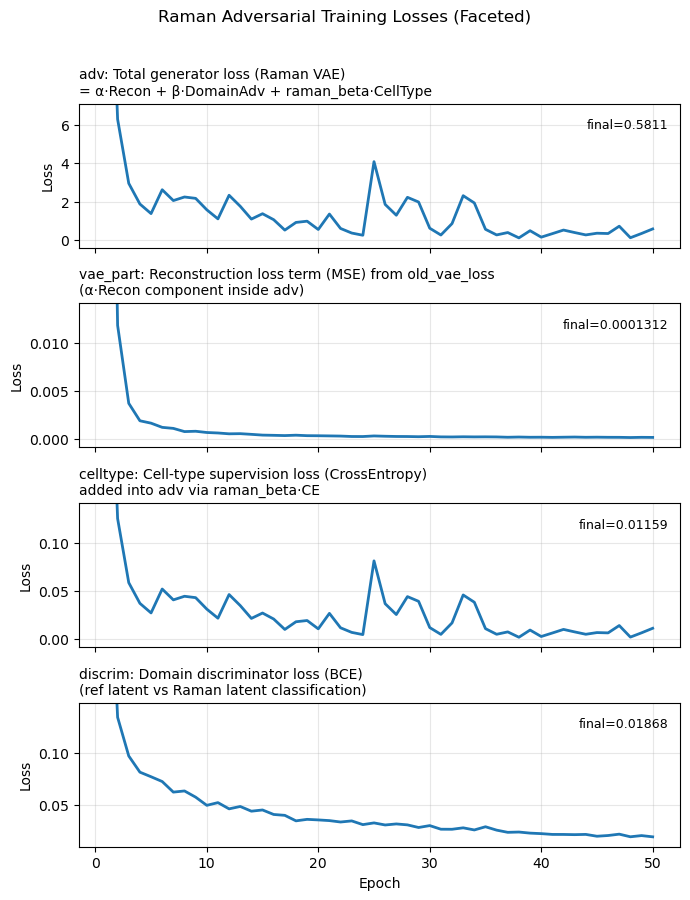

In [47]:
# =========================
# Faceted loss plot: each loss has its own y-axis (subplot)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# ---- safety checks
needed = ["loss_adv", "loss_vae", "loss_celltype", "loss_discrim", "save_figure"]
missing = [k for k in needed if k not in globals()]
if missing:
    print("[Error] Missing variables/functions:", missing)
else:
    # ---- definitions (meaning + style)
    losses = [
        ("adv",       loss_adv,
         "Total generator loss (Raman VAE)\n= α·Recon + β·DomainAdv + raman_beta·CellType",
         "Loss"),
        ("vae_part",  loss_vae,
         "Reconstruction loss term (MSE) from old_vae_loss\n(α·Recon component inside adv)",
         "Loss"),
        ("celltype",  loss_celltype,
         "Cell-type supervision loss (CrossEntropy)\nadded into adv via raman_beta·CE",
         "Loss"),
        ("discrim",   loss_discrim,
         "Domain discriminator loss (BCE)\n(ref latent vs Raman latent classification)",
         "Loss"),
    ]

    n = len(losses)
    epochs = np.arange(1, len(loss_adv) + 1)

    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(7, 9), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (key, series, desc, ylab) in zip(axes, losses):
        series = np.asarray(series, dtype=float)

        ax.plot(epochs, series, lw=2)
        ax.set_ylabel(ylab)
        ax.grid(True, alpha=0.3)

        # Title per panel: name + short meaning
        ax.set_title(f"{key}: {desc}", loc="left", fontsize=10)

        # Annotate last value
        if len(series) > 0 and np.isfinite(series[-1]):
            ax.text(
                0.98, 0.85,
                f"final={series[-1]:.4g}",
                transform=ax.transAxes,
                ha="right", va="center",
                fontsize=9
            )

        # Tight y-limits per panel (robust to outliers)
        if len(series) > 5:
            lo, hi = np.nanpercentile(series, [2, 98])
            if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
                pad = 0.08 * (hi - lo)
                ax.set_ylim(lo - pad, hi + pad)

    axes[-1].set_xlabel("Epoch")
    fig.suptitle("Raman Adversarial Training Losses (Faceted)", y=0.995, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    save_figure(fig, "raman_adversarial_losses_faceted", dpi=300, show=True)

In [48]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ===== Domain discriminator accuracy (should approach 0.5 if aligned) =====
ref_vae = ref_vae.to(device).eval()
raman_vae = raman_vae.to(device).eval()
raman_discrim = raman_discrim.to(device).eval()

with torch.no_grad():
    z_ref = ref_vae.get_latent(torch.from_numpy(train_feature).float().to(get_model_device(ref_vae)))
    z_ram = raman_vae.get_latent(torch.from_numpy(raman_X).float().to(get_model_device(raman_vae)))
    z = torch.cat([z_ref, z_ram], dim=0)
    logits = raman_discrim(z.to(get_model_device(raman_discrim)))
    pred = torch.argmax(logits, dim=1).cpu().numpy()

y = np.array([0]*z_ref.shape[0] + [1]*z_ram.shape[0])
acc = (pred == y).mean()
print("Domain discrim acc:", acc)

Domain discrim acc: 1.0


In [49]:
# =========================
# Measure typical loss scales (no training)
# =========================
import numpy as np
import torch
import torch.nn.functional as F

ref_vae = ref_vae.to(device).eval()
raman_vae = raman_vae.to(device).eval()
raman_discrim = raman_discrim.to(device).eval()
celltype_classifier = celltype_classifier.to(device).eval()

# build a small iterator pair (avoid zip truncation issues)
ref_iter = iter(ref_data_loader)
stats = {"recon": [], "adv_bce": [], "celltype_ce": []}

with torch.no_grad():
    for k, (raman_batch, raman_celltypes) in enumerate(raman_train_loader):
        if k >= 20:
            break
        try:
            (ref_batch,) = next(ref_iter)
        except StopIteration:
            ref_iter = iter(ref_data_loader)
            (ref_batch,) = next(ref_iter)

        ref_batch = ref_batch.to(device)
        raman_batch = raman_batch.to(device)
        raman_celltypes = raman_celltypes.to(device)

        # latents
        z_ref = ref_vae.get_latent(ref_batch)
        z_ram = raman_vae.get_latent(raman_batch)

        # (A) recon MSE (raman_vae recon itself)
        recon_ram, _, _, z_ram2 = raman_vae(raman_batch)
        recon = F.mse_loss(recon_ram, raman_batch).item()

        # (B) domain BCE (discrim tries to tell ref vs raman)
        source_label, target_label = [1.0, 0.0], [0.0, 1.0]
        enc = torch.cat([z_ref, z_ram], dim=0)
        y = torch.tensor([source_label]*z_ref.shape[0] + [target_label]*z_ram.shape[0]).to(device)
        adv_bce = F.binary_cross_entropy_with_logits(raman_discrim(enc), y).item()

        # (C) celltype CE on raman latent
        logits_ct = celltype_classifier(z_ram2)
        ce = criter(logits_ct, raman_celltypes).item()

        stats["recon"].append(recon)
        stats["adv_bce"].append(adv_bce)
        stats["celltype_ce"].append(ce)

for k in stats:
    print(k, "mean=", float(np.mean(stats[k])), "std=", float(np.std(stats[k])))

recon mean= 8.493466375512071e-05 std= 1.4986737577239643e-05
adv_bce mean= 0.01748735932633281 std= 0.003275040840469997
celltype_ce mean= 0.001723953206965234 std= 0.0034023341193980395


/tmp/ipykernel_162429/3519594136.py:44: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_recon = recon_adata_singlecell.concatenate(
/data/liulab/chenming/software/miniforge3/envs/hla_gnn_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


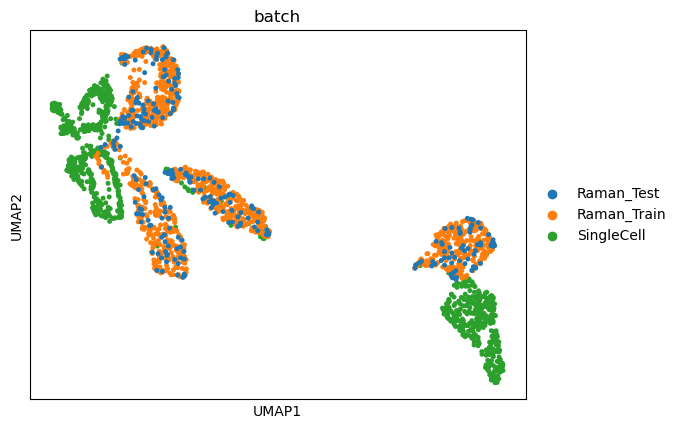

In [50]:
# ==== FIXED (2026-03-19) ====
# cuda-safe numpy conversion for AnnData construction.
# =========================
# FIXED inference: use trained latent BN and eval mode
# =========================
ref_vae = ref_vae.to(device).eval()
raman_vae = raman_vae.to(device).eval()
celltype_classifier = celltype_classifier.to(device).eval()  # optional

with torch.no_grad():
    # 1) SingleCell -> (optional) recon by ref_vae (for comparison)
    orig_sc = torch.from_numpy(train_feature).float().to(device)
    recon_singlecell, _, _, z_sc = ref_vae(orig_sc)

    # 2) Raman train/test -> latent by raman_vae.get_latent (trained BN!) -> decode by ref decoder
    orig_rt = torch.from_numpy(raman_X_train).float().to(device)
    z_rt = raman_vae.get_latent(orig_rt)              # ✅ trained latent normalizer
    recon_raman_train = ref_vae.decoder(z_rt)         # ✅ decode in ref expression space

    orig_rv = torch.from_numpy(raman_X_test).float().to(device)
    z_rv = raman_vae.get_latent(orig_rv)
    recon_raman_test = ref_vae.decoder(z_rv)

# build AnnData (same as you did)
recon_adata_singlecell = sc.AnnData(recon_singlecell.detach().cpu().numpy())
recon_adata_singlecell.obs = train_feature_ad.obs.copy()
recon_adata_singlecell.var_names = train_feature_ad.var_names
recon_adata_singlecell.obs["batch"] = "SingleCell"

recon_adata_raman_train = sc.AnnData(recon_raman_train.detach().cpu().numpy())
recon_adata_raman_train.obs = raman_ad.obs.loc[raman_index_train].copy()
recon_adata_raman_train.var_names = train_feature_ad.var_names
recon_adata_raman_train.obs["batch"] = "Raman_Train"

recon_adata_raman_test = sc.AnnData(recon_raman_test.detach().cpu().numpy())
recon_adata_raman_test.obs = raman_ad.obs.loc[raman_index_test].copy()
recon_adata_raman_test.var_names = train_feature_ad.var_names
recon_adata_raman_test.obs["batch"] = "Raman_Test"

# categorical order
for ad_ in [recon_adata_singlecell, recon_adata_raman_train, recon_adata_raman_test]:
    ad_.obs["cell_type"] = pd.Categorical(ad_.obs["cell_type"], categories=classes, ordered=True)

together_recon = recon_adata_singlecell.concatenate(
    recon_adata_raman_train,
    recon_adata_raman_test,
    batch_key=None,
)

# PCA/UMAP
sc.pp.pca(together_recon, n_comps=30)
sc.pp.neighbors(together_recon, n_neighbors=30)
sc.tl.umap(together_recon)

fig = sc.pl.umap(together_recon, color=["batch"], return_fig=True)
save_figure(fig, "umap_batch_fixed_inference")

/data/liulab/chenming/software/miniforge3/envs/hla_gnn_gpu/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 128 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


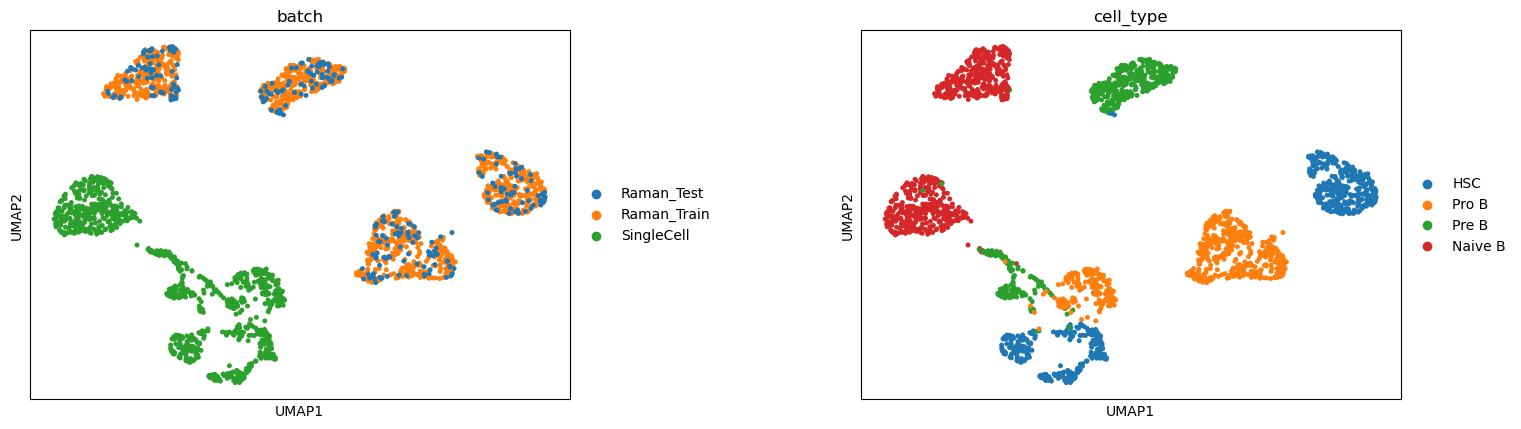

In [66]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# =========================
# UMAP on latent (alignment target space)
# =========================
import numpy as np
import pandas as pd
import scanpy as sc
import torch

ref_vae = ref_vae.to(device).eval()
raman_vae = raman_vae.to(device).eval()

with torch.no_grad():
    z_sc = ref_vae.get_latent(torch.from_numpy(train_feature).float().to(get_model_device(ref_vae)))
    z_rt = raman_vae.get_latent(torch.from_numpy(raman_X_train).float().to(get_model_device(raman_vae)))
    z_rv = raman_vae.get_latent(torch.from_numpy(raman_X_test).float().to(get_model_device(raman_vae)))

Z = np.vstack([z_sc.detach().cpu().numpy(), z_rt.detach().cpu().numpy(), z_rv.detach().cpu().numpy()])

# =========================
# 构建 obs
# =========================
obs = pd.DataFrame(index=
    list(train_feature_ad.obs_names)
    + list(raman_index_train)
    + list(raman_index_test)
)

# batch
obs["batch"] = (
    ["SingleCell"] * z_sc.shape[0]
    + ["Raman_Train"] * z_rt.shape[0]
    + ["Raman_Test"] * z_rv.shape[0]
)

# cell_type（注意索引对齐）
obs["cell_type"] = (
    list(train_feature_ad.obs["cell_type"].values)
    + list(raman_ad.obs.loc[raman_index_train, "cell_type"].values)
    + list(raman_ad.obs.loc[raman_index_test, "cell_type"].values)
)

# 如果你希望类别顺序一致
obs["cell_type"] = pd.Categorical(
    obs["cell_type"],
    categories=classes,
    ordered=True
)

# =========================
# 构建 AnnData
# =========================
latent_adata = sc.AnnData(Z, obs=obs)

# 不需要 PCA，latent 已经是低维
sc.pp.neighbors(latent_adata, n_neighbors=30, metric="cosine")
sc.tl.umap(latent_adata)

# =========================
# 画图
# =========================
fig = sc.pl.umap(
    latent_adata,
    color=["batch", "cell_type"],
    wspace=0.4,
    return_fig=True
)

save_figure(fig, "umap_latent_batch_celltype")

In [67]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ==== MODIFIED (2026-03-19) ====
# Purpose: Use use_latent_norm=False in transfer_vae to match training config.
# ===============================
# =========================
# Part B1: get inferred expression from Raman via transfer_vae
# =========================
import numpy as np
import torch
import scanpy as sc
import scipy as sp

transfer_vae = VAE(
    raman_vae.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=False,
).to(device).eval()

ref_vae = ref_vae.to(device).eval()

with torch.no_grad():
    inferred_rt, _, _, latent_rt = transfer_vae(torch.from_numpy(raman_X_train).float().to(get_model_device(transfer_vae)))
    inferred_rv, _, _, latent_rv = transfer_vae(torch.from_numpy(raman_X_test).float().to(get_model_device(transfer_vae)))

inferred_rt = inferred_rt.detach().cpu().numpy()
inferred_rv = inferred_rv.detach().cpu().numpy()

# 对齐基因名（就是 HVGs）
gene_names = np.array(train_feature_ad.var_names)

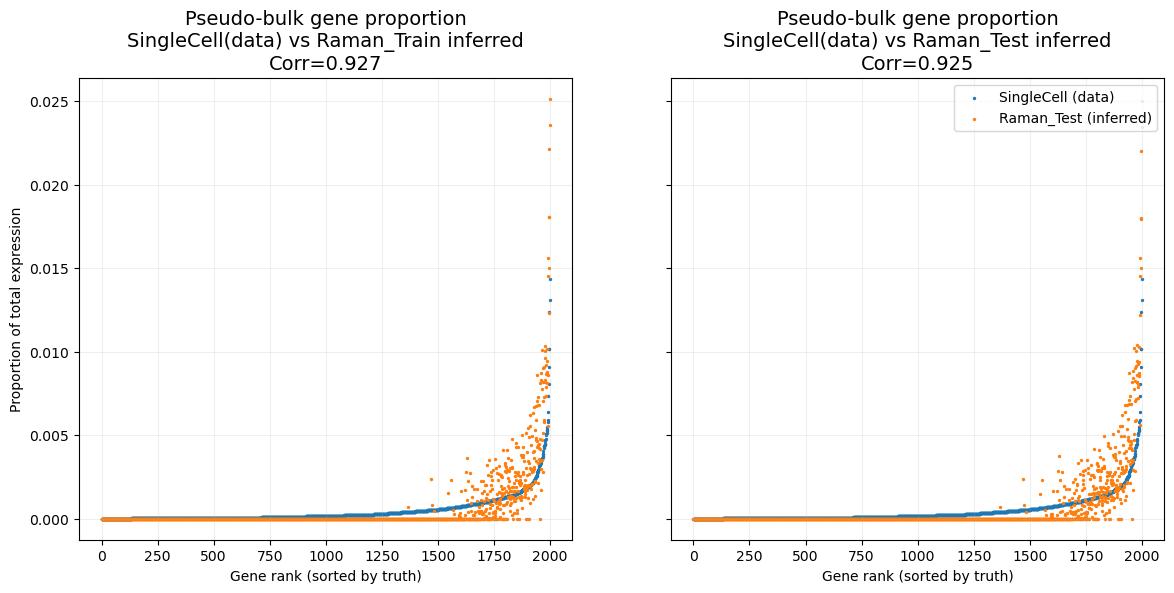

Pseudo-bulk proportion corr (train): 0.9269996625127441
Pseudo-bulk proportion corr (test): 0.9254407246733259


In [68]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1) truth：用 data layer (lognorm, non-negative)
if torch.is_tensor(inferred_rt):
    inferred_rt = inferred_rt.detach().cpu().numpy()
if torch.is_tensor(inferred_rv):
    inferred_rv = inferred_rv.detach().cpu().numpy()

X_truth = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)

# 2) inferred：transfer 输出（你的是非负）
X_rt = np.asarray(inferred_rt, dtype=np.float32)
X_rv = np.asarray(inferred_rv, dtype=np.float32)

# safety：确保非负（理论上 inferred 已经非负）
X_truth = np.clip(X_truth, 0, None)
X_rt    = np.clip(X_rt, 0, None)
X_rv    = np.clip(X_rv, 0, None)

# pseudo-bulk gene proportion
orig_sum = X_truth.sum(axis=0) / (X_truth.sum() + 1e-12)
inf_sum_rt = X_rt.sum(axis=0) / (X_rt.sum() + 1e-12)
inf_sum_rv = X_rv.sum(axis=0) / (X_rv.sum() + 1e-12)

corr_rt = np.corrcoef(orig_sum, inf_sum_rt)[0, 1]
corr_rv = np.corrcoef(orig_sum, inf_sum_rv)[0, 1]

ord_idx = np.argsort(orig_sum)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
s = 2

axes[0].set_title(f"Pseudo-bulk gene proportion\nSingleCell(data) vs Raman_Train inferred\nCorr={corr_rt:.3f}", fontsize=14)
axes[0].scatter(np.arange(len(orig_sum)), orig_sum[ord_idx], s=s, label="SingleCell (data)")
axes[0].scatter(np.arange(len(orig_sum)), inf_sum_rt[ord_idx], s=s, label="Raman_Train (inferred)")
axes[0].set_xlabel("Gene rank (sorted by truth)")
axes[0].set_ylabel("Proportion of total expression")
axes[0].grid(True, alpha=0.2)

axes[1].set_title(f"Pseudo-bulk gene proportion\nSingleCell(data) vs Raman_Test inferred\nCorr={corr_rv:.3f}", fontsize=14)
axes[1].scatter(np.arange(len(orig_sum)), orig_sum[ord_idx], s=s, label="SingleCell (data)")
axes[1].scatter(np.arange(len(orig_sum)), inf_sum_rv[ord_idx], s=s, label="Raman_Test (inferred)")
axes[1].set_xlabel("Gene rank (sorted by truth)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.2)

save_figure(fig, "expr_pseudobulk_gene_proportion_corr_FIXED")
print("Pseudo-bulk proportion corr (train):", corr_rt)
print("Pseudo-bulk proportion corr (test):", corr_rv)

In [69]:
import numpy as np
import torch

if torch.is_tensor(inferred_rt):
    inferred_rt = inferred_rt.detach().cpu().numpy()
if torch.is_tensor(inferred_rv):
    inferred_rv = inferred_rv.detach().cpu().numpy()

X_truth = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)   # lognorm
X_rt = np.asarray(inferred_rt, dtype=np.float32)
X_rv = np.asarray(inferred_rv, dtype=np.float32)

def summarize(name, X):
    row_sum = X.sum(axis=1)
    print(f"\n[{name}]")
    print("  shape:", X.shape)
    print("  min/max:", float(X.min()), float(X.max()))
    print("  row_sum mean/std:", float(row_sum.mean()), float(row_sum.std()))
    print("  pct zeros:", float((X == 0).mean()))
    # top-10 genes占比是否极端
    col_sum = X.sum(axis=0)
    p = col_sum / (col_sum.sum() + 1e-12)
    top10 = np.sort(p)[-10:].sum()
    print("  top10 gene proportion sum:", float(top10))

summarize("truth(data layer)", X_truth)
summarize("inferred Raman_Train", X_rt)
summarize("inferred Raman_Test", X_rv)


[truth(data layer)]
  shape: (938, 2000)
  min/max: 0.0 8.895095825195312
  row_sum mean/std: 410.4887390136719 77.89970397949219
  pct zeros: 0.8857627931769723
  top10 gene proportion sum: 0.09697109460830688

[inferred Raman_Train]
  shape: (1132, 2000)
  min/max: 0.0 6.215063095092773
  row_sum mean/std: 221.2186279296875 36.069522857666016
  pct zeros: 0.8931576855123675
  top10 gene proportion sum: 0.1748383343219757

[inferred Raman_Test]
  shape: (283, 2000)
  min/max: 0.0 6.209319591522217
  row_sum mean/std: 223.03939819335938 35.28364181518555
  pct zeros: 0.8923586572438162
  top10 gene proportion sum: 0.1742507964372635


In [70]:
# ==== FIXED (2026-03-19) ====
# Remove forward-reference to original_omics; use SC normalized truth directly.
# =========================
# Part B3: pseudo-bulk correlation per cell_type
# =========================
import pandas as pd
import numpy as np

cell_sc = train_feature_ad.obs["cell_type"].astype(str).values
cell_rt = raman_ad.obs.loc[raman_index_train, "cell_type"].astype(str).values
cell_rv = raman_ad.obs.loc[raman_index_test,  "cell_type"].astype(str).values

def per_celltype_pseudobulk_corr(X_truth, ct_truth, X_infer, ct_infer, classes):
    rows = []
    for ct in classes:
        ct = str(ct)
        idx_t = (ct_truth == ct)
        idx_i = (ct_infer == ct)
        if idx_t.sum() < 5 or idx_i.sum() < 5:
            continue
        t = X_truth[idx_t].mean(axis=0)
        i = X_infer[idx_i].mean(axis=0)
        r = np.corrcoef(t, i)[0, 1]
        rows.append({"cell_type": ct, "n_truth": int(idx_t.sum()), "n_infer": int(idx_i.sum()), "pearson_r": float(r)})
    return pd.DataFrame(rows).sort_values("pearson_r", ascending=False)

X_truth_ct = ensure_dense(train_feature_ad.layers["data"]).astype(np.float32)

df_ct_rt = per_celltype_pseudobulk_corr(X_truth_ct, cell_sc, inferred_rt, cell_rt, classes)
df_ct_rv = per_celltype_pseudobulk_corr(X_truth_ct, cell_sc, inferred_rv, cell_rv, classes)

print("Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Train inferred")
print(df_ct_rt)

print("\nPer-cell_type pseudo-bulk corr: SingleCell vs Raman_Test inferred")
print(df_ct_rv)

Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Train inferred
  cell_type  n_truth  n_infer  pearson_r
1     Pro B      175      345   0.932860
3   Naive B      345      260   0.931194
0       HSC      264      263   0.924472
2     Pre B      154      264   0.920521

Per-cell_type pseudo-bulk corr: SingleCell vs Raman_Test inferred
  cell_type  n_truth  n_infer  pearson_r
1     Pro B      175       86   0.933161
3   Naive B      345       65   0.932193
2     Pre B      154       66   0.922130
0       HSC      264       66   0.918579


In [71]:
import numpy as np

print("train_feature min/max:", float(train_feature.min()), float(train_feature.max()))
print("inferred_rt min/max:", float(inferred_rt.min()), float(inferred_rt.max()))
print("inferred_rv min/max:", float(inferred_rv.min()), float(inferred_rv.max()))

train_feature min/max: 0.0 8.895095825195312
inferred_rt min/max: 0.0 6.215063095092773
inferred_rv min/max: 0.0 6.209319591522217


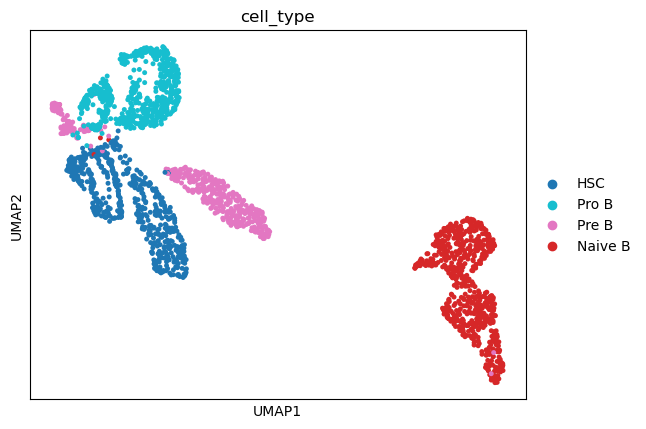

In [72]:
fig = sc.pl.umap(together_recon, color=["cell_type"], palette=palette, return_fig=True)
save_figure(fig, "umap_cell_type")


In [73]:
# Validation 3: Quantify batch mixing on UMAP (fraction of kNN from other batch)
import sklearn.neighbors as skn

umap = together_recon.obsm["X_umap"]
labels_batch = together_recon.obs["batch"].values

k = 30
nbrs = skn.NearestNeighbors(n_neighbors=k+1).fit(umap)
_, idxs = nbrs.kneighbors(umap)

# exclude self (first neighbor)
idxs = idxs[:, 1:]

mix_scores = []
for i in range(umap.shape[0]):
    neighbors = labels_batch[idxs[i]]
    mix = np.mean(neighbors != labels_batch[i])
    mix_scores.append(mix)

print(f"UMAP kNN mixing (k={k}) mean: {np.mean(mix_scores):.3f}")


UMAP kNN mixing (k=30) mean: 0.230


In [74]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ======================================================
# Raman->SC ROC + Accuracy Table (like the provided figure)
# ======================================================
# Use transfer_vae to map Raman to SC space, then use SC classifier
transfer_vae_eval = transfer_vae.to(device).eval()
ref_vae_eval = ref_vae.to(device).eval()
celltype_classifier_eval = celltype_classifier.to(device).eval()

with torch.no_grad():
    raman_recon, _, _, _ = transfer_vae_eval(torch.tensor(raman_X, dtype=torch.float32, device=get_model_device(transfer_vae_eval)))
    _, _, _, latent_raman2sc = ref_vae_eval(raman_recon.to(get_model_device(ref_vae_eval)))
    logits = celltype_classifier_eval(latent_raman2sc.to(get_model_device(celltype_classifier_eval)))
    probs = torch.softmax(logits, dim=1).cpu().numpy()

raman_labels = raman_y
pred = np.argmax(probs, axis=1)

# Build table
rows = []
for i, ct in enumerate(classes):
    idx = raman_labels == i
    members = int(idx.sum())
    correct = int((pred[idx] == i).sum())
    acc = 100.0 * correct / max(members, 1)
    counts = [int(((pred[idx] == j).sum())) for j in range(len(classes))]
    rows.append([ct, members, f"{acc:.2f}%"] + counts)

total_members = len(raman_labels)
correct_total = int((pred == raman_labels).sum())
acc_total = 100.0 * correct_total / max(total_members, 1)
counts_total = [int((pred == j).sum()) for j in range(len(classes))]
rows.append(["Total", total_members, f"{acc_total:.2f}%"] + counts_total)

cols = ["True", "Members", "Correct"] + list(classes)
acc_table = pd.DataFrame(rows, columns=cols)
acc_table


,True,Members,Correct,HSC,Pro B,Pre B,Naive B
0,HSC,329,98.18%,323,0,3,3
1,Pro B,325,100.00%,0,325,0,0
2,Pre B,330,100.00%,0,0,330,0
3,Naive B,431,100.00%,0,0,0,431
4,Total,1415,99.58%,323,325,333,434


In [75]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# Validation 2: Compare classifier ROC on Raman->SC reconstructed vs true SC
# (if the ROC degrades on Raman->SC, that indicates a domain gap)

# Build latent for Raman->SC data (through transfer_vae + ref encoder)
transfer_vae_eval = transfer_vae.to(device).eval()
ref_vae_eval = ref_vae.to(device).eval()

with torch.no_grad():
    # Raman->SC reconstruction, then encode with ref_vae encoder for classifier
    raman_recon, _, _, _ = transfer_vae_eval(torch.tensor(raman_X, dtype=torch.float32, device=get_model_device(transfer_vae_eval)))
    _, _, _, latent_raman2sc = ref_vae_eval(raman_recon.to(get_model_device(ref_vae_eval)))

latent_raman2sc = latent_raman2sc.numpy()
raman_labels = raman_y

# Use the already trained classifier (celltype_classifier) to score Raman->SC
celltype_classifier_eval = celltype_classifier.to(device).eval()
with torch.no_grad():
    logits = celltype_classifier_eval(torch.tensor(latent_raman2sc, dtype=torch.float32, device=get_model_device(celltype_classifier_eval)))
    probs = torch.softmax(logits, dim=1).cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 5))
y_bin = label_binarize(raman_labels, classes=list(range(len(classes))))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC on Raman->SC (using SC classifier)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
save_figure(fig, "classifier_roc_raman2sc")


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [76]:
marker_genes_dict_3to5 = {
    "HSC": ["CD34", "PROM1", "KIT", "GATA2", "MEIS1"],
    "Pro B": ["CYGB", "EBF1", "MME", "VPREB1", "DNTT", "IGLL1"],
    "Pre B": ["PAX5", "CD79A", "RAG1"],
    "Naive B": ["MS4A1", "CD74", "CD37", "BANK1", "TCL1A"],
}


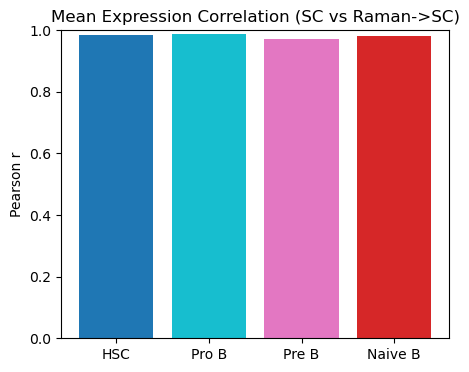

,cell_type,corr
0,HSC,0.983705
1,Pro B,0.987777
2,Pre B,0.972709
3,Naive B,0.980529


In [77]:
# ==================================================================
# Cell-type mean expression correlation: SC vs Raman->SC (per cell type)
# ==================================================================
# Use together_recon with batch labels (SingleCell vs Raman_Train)

corr_rows = []
for ct in classes:
    sc_sub = together_recon[(together_recon.obs["cell_type"] == ct) & (together_recon.obs["batch"] == "SingleCell")]
    rm_sub = together_recon[(together_recon.obs["cell_type"] == ct) & (together_recon.obs["batch"] == "Raman_Train")]
    if sc_sub.n_obs == 0 or rm_sub.n_obs == 0:
        continue

    sc_expr = sc_sub.X
    rm_expr = rm_sub.X
    if sp.sparse.issparse(sc_expr):
        sc_expr = sc_expr.toarray()
    if sp.sparse.issparse(rm_expr):
        rm_expr = rm_expr.toarray()

    sc_mean = sc_expr.mean(axis=0)
    rm_mean = rm_expr.mean(axis=0)
    corr = np.corrcoef(sc_mean, rm_mean)[0, 1]
    corr_rows.append({"cell_type": ct, "corr": corr})

corr_df = pd.DataFrame(corr_rows)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(corr_df["cell_type"], corr_df["corr"], color=palette)
ax.set_ylim(0, 1)
ax.set_title("Mean Expression Correlation (SC vs Raman->SC)")
ax.set_ylabel("Pearson r")
save_figure(fig, "mean_expr_corr_sc_vs_raman")

corr_df


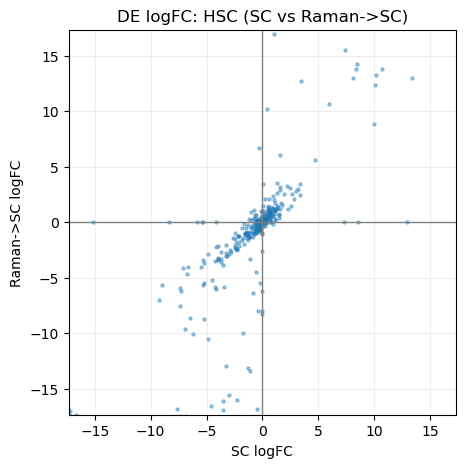

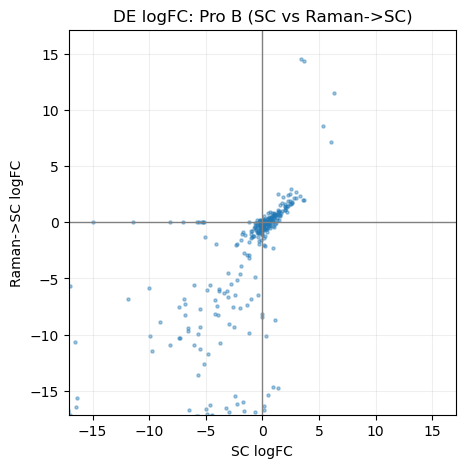

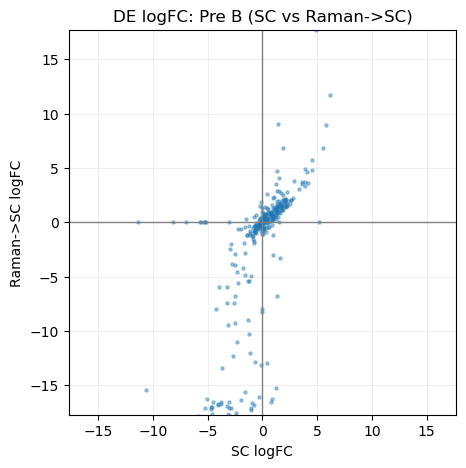

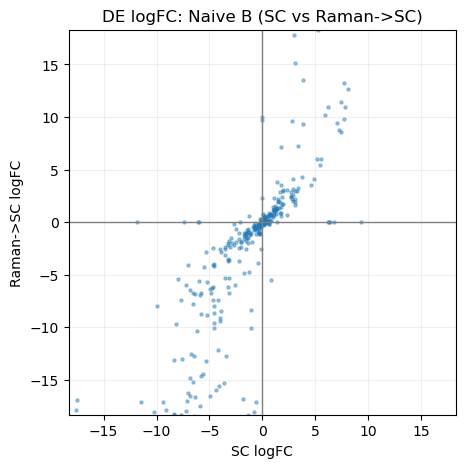

In [78]:
# =================================================
# DE gene logFC comparison (SC vs Raman->SC)
# =================================================
# Compute logFC per cell type vs rest, then compare between SC and Raman->SC

def logfc_vs_rest(adata, group_key, target_group, eps=1e-6):
    X = adata.X
    if sp.sparse.issparse(X):
        X = X.toarray()
    labels = adata.obs[group_key].astype(str).values
    mask = labels == target_group
    mean_in = X[mask].mean(axis=0) + eps
    mean_out = X[~mask].mean(axis=0) + eps
    return np.log2(mean_in / mean_out)

# Use only genes shared in together_recon
genes = list(together_recon.var_names)

sc_adata = together_recon[together_recon.obs["batch"] == "SingleCell"]
rm_adata = together_recon[together_recon.obs["batch"] == "Raman_Train"]

for ct in classes:
    if ct not in sc_adata.obs["cell_type"].astype(str).unique():
        continue
    if ct not in rm_adata.obs["cell_type"].astype(str).unique():
        continue

    sc_logfc = logfc_vs_rest(sc_adata, "cell_type", ct)
    rm_logfc = logfc_vs_rest(rm_adata, "cell_type", ct)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(sc_logfc, rm_logfc, s=5, alpha=0.4)
    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1)
    lim = np.percentile(np.abs(np.concatenate([sc_logfc, rm_logfc])), 99)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(f"DE logFC: {ct} (SC vs Raman->SC)")
    ax.set_xlabel("SC logFC")
    ax.set_ylabel("Raman->SC logFC")
    ax.grid(True, alpha=0.2)
    save_figure(fig, f"logfc_sc_vs_raman_{ct.replace(' ', '_')}")


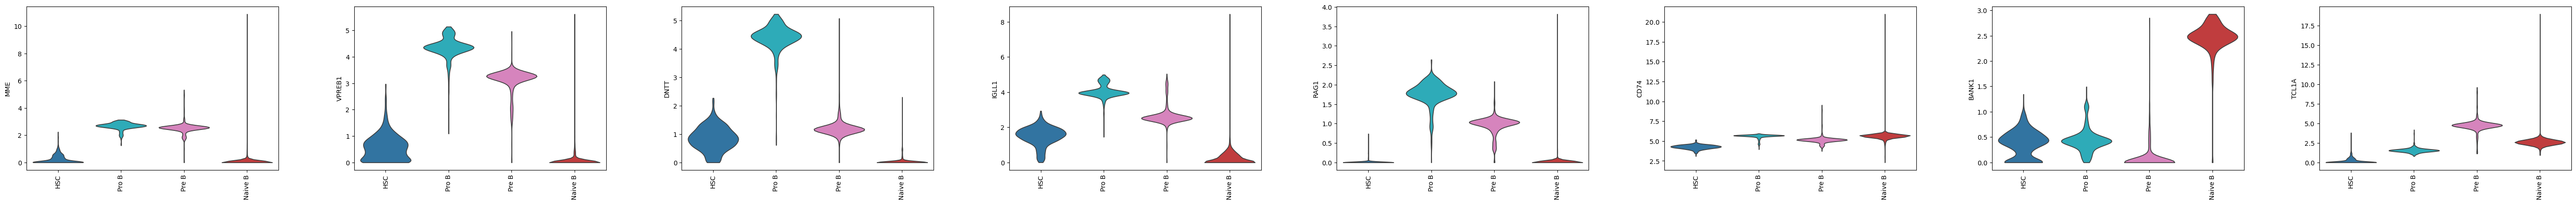

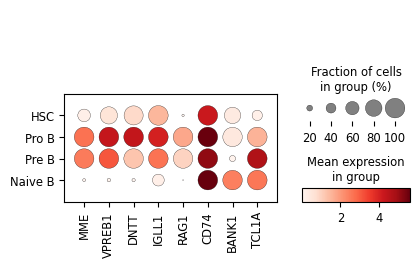

In [79]:
# =================================================
# Marker genes: violin + dotplot (SC vs Raman->SC)
# =================================================
marker_genes = []
for ct, genes in marker_genes_dict_3to5.items():
    marker_genes.extend(genes)
marker_genes = list(dict.fromkeys(marker_genes))
marker_genes = [g for g in marker_genes if g in together_recon.var_names]

# Violin plots split by batch
fig = sc.pl.violin(
    together_recon,
    keys=marker_genes,
    groupby="cell_type",
    stripplot=False,
    multi_panel=True,
    rotation=90,
    show=False,
)
fig = plt.gcf()
save_figure(fig, "marker_genes_violin")

# Dotplot
sc.pl.dotplot(
    together_recon,
    var_names=marker_genes,
    groupby="cell_type",
    use_raw=False,
    show=False,
)
fig = plt.gcf()
save_figure(fig, "marker_genes_dotplot")


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26532\659399986.py:49: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_noadv = sc_adata.concatenate(recon_noadv, batch_key=None)
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


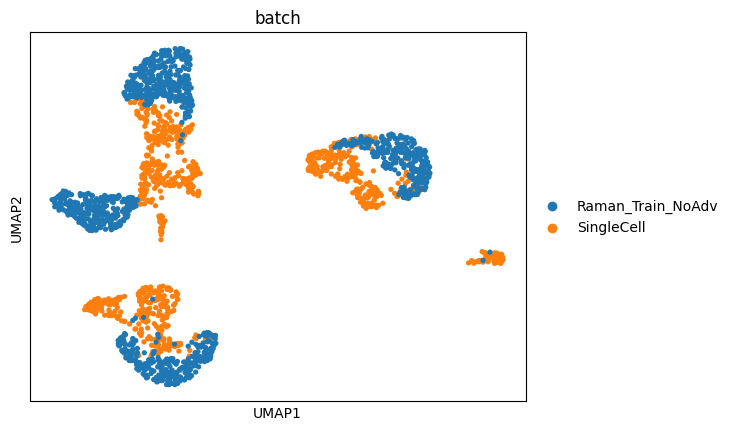

In [35]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ==== MODIFIED (2026-03-19) ====
# Purpose: In No-Adv ablation, use no latent BN for consistency with the main setup.
# ===============================
# -----------------------------
# Ablation 1: No adversarial (only Raman VAE + classifier)
# -----------------------------

def train_raman_no_adv(epochs=20):
    raman_vae_na = VAE(
        StandardEncoder(input_cell_dim, latent_dim, hidden_dim=1 << 11),
        StandardDecoder(input_cell_dim, latent_dim, hidden_dim=1 << 11, no_final_relu=True),
        is_vae=False,
        use_latent_norm=False,
    ).to(device)
    opt = optim.Adam(raman_vae_na.parameters(), lr=5e-5)

    # ensure classifier on same device
    clf = celltype_classifier.to(device)

    for epoch in range(epochs):
        for raman_batch, raman_celltypes in raman_train_loader:
            raman_batch = raman_batch.to(device)
            raman_celltypes = raman_celltypes.to(device)
            opt.zero_grad()
            recon, mean, logvar, latent = raman_vae_na(raman_batch)
            loss = old_vae_loss(raman_batch, recon, mean, logvar)
            # add classifier loss to keep supervision
            preds = clf(raman_vae_na.get_latent(raman_batch))
            loss = loss + raman_beta * criter(preds, raman_celltypes)
            loss.backward()
            opt.step()
    return raman_vae_na

raman_vae_no_adv = train_raman_no_adv(epochs=20)

transfer_no_adv = VAE(
    raman_vae_no_adv.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=False,
).to(device)

with torch.no_grad():
    recon_raman_train_noadv, _, _, _ = transfer_no_adv(torch.tensor(raman_X_train, dtype=torch.float32, device=get_model_device(transfer_no_adv)))

recon_noadv = sc.AnnData(recon_raman_train_noadv.numpy())
recon_noadv.obs = raman_ad.obs.loc[raman_index_train].copy()
recon_noadv.obs["batch"] = "Raman_Train_NoAdv"
recon_noadv.var_names = train_feature_ad.var_names

sc_adata = recon_adata_singlecell.copy()
together_noadv = sc_adata.concatenate(recon_noadv, batch_key=None)

sc.pp.pca(together_noadv, n_comps=30)
sc.pp.neighbors(together_noadv, n_neighbors=30)
sc.tl.umap(together_noadv)

fig = sc.pl.umap(together_noadv, color=["batch"], return_fig=True)
save_figure(fig, "umap_no_adv_batch")


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26532\2706959842.py:65: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  together_noct = sc_adata.concatenate(recon_noct, batch_key=None)
g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


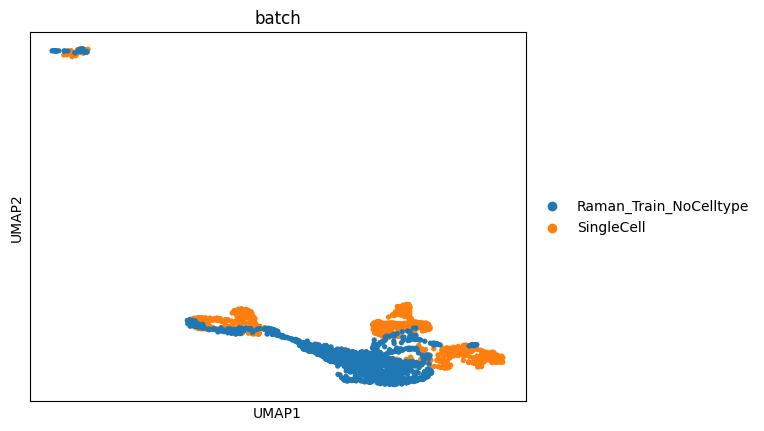

In [37]:
# ==== FIXED (2026-03-19) ====
# Device-safe tensor/model placement to avoid CPU/GPU mismatch.
# ==== MODIFIED (2026-03-19) ====
# Purpose: In No-Celltype ablation, use no latent BN for consistency with the main setup.
# ===============================
# -----------------------------
# Ablation 2: No celltype loss (adversarial only)
# -----------------------------

def train_raman_no_celltype(epochs=20):
    # ensure ref_vae on device for latent extraction
    ref_vae.to(device)

    raman_vae_nc = VAE(
        StandardEncoder(input_cell_dim, latent_dim, hidden_dim=1 << 11),
        StandardDecoder(input_cell_dim, latent_dim, hidden_dim=1 << 11, no_final_relu=True),
        is_vae=False,
        use_latent_norm=False,
    ).to(device)
    opt = optim.Adam(raman_vae_nc.parameters(), lr=5e-5)

    discrim = Discriminator(latent_dim).to(device)
    dopt = optim.Adam(discrim.parameters(), lr=4e-3)

    for epoch in range(epochs):
        for ([ref_batch], [raman_batch, raman_celltypes]) in zip(ref_data_loader, raman_train_loader):
            ref_batch = ref_batch.to(device)
            raman_batch = raman_batch.to(device)

            dopt.zero_grad()
            ref_lat = ref_vae.get_latent(ref_batch).detach()
            ram_lat = raman_vae_nc.get_latent(raman_batch).detach()
            enc = torch.cat([ref_lat, ram_lat], axis=0)
            labels = torch.tensor([[1.0, 0.0]] * ref_lat.shape[0] + [[0.0, 1.0]] * ram_lat.shape[0]).to(device)
            pred = discrim(enc)
            dloss = discrim_loss(pred, labels)
            dloss.backward()
            dopt.step()

            for p in discrim.parameters():
                p.requires_grad = False
            opt.zero_grad()
            recon, mean, logvar, lat = raman_vae_nc(raman_batch)
            preds = discrim(lat)
            loss, _, _ = adv_vae_loss(raman_batch, recon, mean, logvar, preds, alpha, beta)
            loss.backward()
            opt.step()
            for p in discrim.parameters():
                p.requires_grad = True
    return raman_vae_nc

raman_vae_no_celltype = train_raman_no_celltype(epochs=20)

transfer_no_ct = VAE(
    raman_vae_no_celltype.encoder,
    ref_vae.decoder,
    is_vae=False,
    use_latent_norm=False,
).to(device)

with torch.no_grad():
    recon_raman_train_noct, _, _, _ = transfer_no_ct(torch.tensor(raman_X_train, dtype=torch.float32, device=get_model_device(transfer_no_ct)))

recon_noct = sc.AnnData(recon_raman_train_noct.numpy())
recon_noct.obs = raman_ad.obs.loc[raman_index_train].copy()
recon_noct.obs["batch"] = "Raman_Train_NoCelltype"
recon_noct.var_names = train_feature_ad.var_names

sc_adata = recon_adata_singlecell.copy()
together_noct = sc_adata.concatenate(recon_noct, batch_key=None)

sc.pp.pca(together_noct, n_comps=30)
sc.pp.neighbors(together_noct, n_neighbors=30)
sc.tl.umap(together_noct)

fig = sc.pl.umap(together_noct, color=["batch"], return_fig=True)
save_figure(fig, "umap_no_celltype_batch")
